## Notebook to test fine-tuning of prelim FM

In [36]:
import os
import random
import numpy as np
import torch

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)

In [37]:
import torch
from icu_benchmarks.models.dl_models.bat import * 

model_path = "/work3/s185395/yaib_logs/eicu_miiv/LOS/SSL_BAT_no_tune/2025-05-23T16-53-41/repetition_0/fold_0/model.ckpt"
ckpt = torch.load(model_path, map_location="cpu")

/tmp/ipykernel_1173815/1259975994.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location="cpu")


In [38]:
T = 24  # Try T = 215 for now

input_size = (1, 48, T) 
vemb = 256

model = SSL_BAT(
    input_size=input_size,
    value_embed_size=vemb,
    layers=2,
    heads=1,
    dropout=0,
    attn_dropout=0,
    use_mask=False,
    prediction_head = ForecastingHead,
    prediction_head_kwargs = {
  "sensors_count": 48,
  "forecast_len": 2,
}
)

use static


In [39]:
# Load only encoder weights
encoder_state_dict = {k.replace("model.encoder_class.", ""): v
                      for k, v in ckpt["state_dict"].items()
                      if k.startswith("model.encoder_class.")}

model.model.encoder_class.load_state_dict(encoder_state_dict)


<All keys matched successfully>

In [258]:
# Only needed if wanting to load all weights (including fiorecasting head)

# Dummy input to trigger model.head creation
#dummy_input = torch.randn(1, 48, T)
#dummy_static = torch.randn(1, 4)
#dummy_time = torch.arange(T).unsqueeze(0).repeat(1, 1)  # shape: (1, 215)
#dummy_mask = torch.ones_like(dummy_input)

# Forward pass to create model.model.head
#with torch.no_grad():
#    _ = model(dummy_input, dummy_static, dummy_time, dummy_mask)

# Now inspect head shape
#print(model.model.head.linear.weight.shape)
#print(model.model.head.linear.bias.shape)

#model.load_state_dict(ckpt["state_dict"])
#print("✅ Loaded weights into model.")



In [40]:
# Extract encoder from SSL_BAT
pretrained_encoder = model.model.encoder_class


In [41]:
# Freeze encoder weights
for param in pretrained_encoder.parameters():
    param.requires_grad = False  # optional

In [42]:
# Create classification model using the pretrained encoder
classification_model = EncoderPrediction(
    encoder_class=pretrained_encoder,
    prediction_head=BinaryClassificationHead,
    prediction_head_kwargs={"num_classes": 2}
)

In [43]:
# 4. Do a forward pass to initialize the classification head
dummy_input = torch.randn(1, 48, T)
dummy_static = torch.randn(1, 4)
dummy_time = torch.linspace(0, 1440, T).unsqueeze(0)  # shape: (1, T)
dummy_mask = torch.ones_like(dummy_input)


In [44]:
with torch.no_grad():
    _ = classification_model(dummy_input, dummy_static, dummy_time, dummy_mask)

[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 24])
[DEBUG] Min/max time: 0.0 1440.0


## Add new head to pretrained mdoel

## Load in harmonized mimic

In [45]:
import os
import copy
import logging

import gin
import json
import hashlib
import pandas as pd
import polars as pl
from pathlib import Path
import pickle
from timeit import default_timer as timer
from sklearn.model_selection import StratifiedKFold, KFold, StratifiedShuffleSplit, ShuffleSplit
from icu_benchmarks.data.preprocessor import Preprocessor, PandasClassificationPreprocessor, PolarsClassificationPreprocessor
from icu_benchmarks.constants import RunMode
from icu_benchmarks.run_utils import check_required_keys
from icu_benchmarks.data.constants import DataSplit as Split, DataSegment as Segment, VarType as Var

from icu_benchmarks.data.split_process_data import *
from icu_benchmarks.cross_validation import execute_repeated_cv  # adjust if path is different
from icu_benchmarks.run import *

In [46]:
vars_dict = {
    "GROUP": "stay_id",
    "SEQUENCE": "time",
    "LABEL": "label",
    "DYNAMIC": ["alb", "alp", "alt", "ast", "be", "bicar", "bili", "bili_dir", "bnd", "bun", "ca", "cai", "ck", "ckmb", "cl",
        "crea", "crp", "dbp", "fgn", "fio2", "glu", "hgb", "hr", "inr_pt", "k", "lact", "lymph", "map", "mch", "mchc", "mcv",
        "methb", "mg", "na", "neut", "o2sat", "pco2", "ph", "phos", "plt", "po2", "ptt", "resp", "sbp", "temp", "tnt", "urine",
        "wbc"],
    "STATIC": ["age", "sex", "height", "weight"],
}

# Load the gin config
gin.parse_config_file("/work3/s185395/YAIB/configs/tasks/BinaryClassification.gin")


ParsedConfigFileIncludesAndImports(filename='/work3/s185395/YAIB/configs/tasks/BinaryClassification.gin', imports=[], includes=[ParsedConfigFileIncludesAndImports(filename='configs/tasks/common/Imports.gin', imports=['icu_benchmarks.data.split_process_data', 'icu_benchmarks.data.loader', 'icu_benchmarks.models.wrappers', 'icu_benchmarks.models.dl_models', 'icu_benchmarks.models.ml_models'], includes=[]), ParsedConfigFileIncludesAndImports(filename='configs/tasks/common/PredictionTaskVariables.gin', imports=[], includes=[]), ParsedConfigFileIncludesAndImports(filename='configs/tasks/common/CrossValidation.gin', imports=[], includes=[]), ParsedConfigFileIncludesAndImports(filename='configs/tasks/common/Dataloader.gin', imports=[], includes=[])])

In [47]:
# Call the preprocessing function with the new scale
data = preprocess_data(
    data_dir=Path("/work3/s185395/YAIB-cohorts/data/mortality24/mimic"),
    #data_dir=Path("/work3/s185395/YAIB-cohorts/data/mortality24/miiv"),
    seed=2222,
    generate_cache=True,
    load_cache=False,
    debug=False,
    use_static = True,
    runmode=RunMode.classification
)

In [53]:
from torch.utils.data import random_split
from icu_benchmarks.data.loader import *
from torch.utils.data import DataLoader

seed = 42 
split = False # Change depending on what data to use

if split:
    # Load test set 
    test_dataset = BATPolarsDataset(data=data, split="test", ram_cache=False, runmode=RunMode.classification)
    #test_loader = DataLoader(test_dataset, batch_size=128, collate_fn=test_dataset.collate_fn_pad_to_longest_in_batch()) # maybe change bz chgange log of that run 
    print(f'Test dataset length: {len(test_dataset)}')

    # Split the test set for fine-tuening 
    dataset_len = len(test_dataset)
    finetune_len = dataset_len // 2
    eval_len = dataset_len - finetune_len

    finetune_set, eval_set = random_split(test_dataset, [finetune_len, eval_len])

    finetune_loader = DataLoader(finetune_set, batch_size=64, shuffle=True,
                                collate_fn=test_dataset.collate_fn_pad_to_longest_in_batch())
    eval_loader = DataLoader(eval_set, batch_size=64, shuffle=False,
                            collate_fn=test_dataset.collate_fn_pad_to_longest_in_batch())

    print(f'Finetuening dataset length: {len(finetune_set)}')
    print(f'Evaluation dataset length: {len(eval_set)}')

else:
    finetune_set = BATPolarsDataset(data=data, split="train", ram_cache=False, runmode=RunMode.classification)
    eval_set = BATPolarsDataset(data=data, split="test", ram_cache=False, runmode=RunMode.classification)

    finetune_loader = DataLoader(finetune_set, batch_size=1, shuffle=True,
                                collate_fn=finetune_set.collate_fn_pad_to_longest_in_batch())
    eval_loader = DataLoader(eval_set, batch_size=1, shuffle=False,
                            collate_fn=eval_set.collate_fn_pad_to_longest_in_batch())

    print(f'Finetuening dataset length: {len(finetune_set)}')
    print(f'Evaluation dataset length: {len(eval_set)}')


Finetuening dataset length: 9506
Evaluation dataset length: 2971


In [ ]:
import torch
from torchmetrics.classification import BinaryAUROC, BinaryAveragePrecision

# Zero shot 

# Automatically select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Using device: {device}")

# Freeze model parameters and set to eval mode
for param in classification_model.parameters():
    param.requires_grad = False
classification_model.eval()

# Move model to device
zero_shot_model = classification_model.to(device)
zero_shot_model.eval()

# Metrics
auroc_metric = BinaryAUROC().to(device)
prauc_metric = BinaryAveragePrecision().to(device)

all_probs = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(eval_loader, desc="Zero-shot Classification"):
        x, mask, label, times, static, *_ = batch

        x = x.to(device).to(torch.float32)
        mask = mask.to(device).to(torch.float32)
        times = times.to(device).to(torch.float32)
        static = static.to(device).to(torch.float32)
        label = label.to(device).long()

        # added to work for bz of 1 
        if label.dim() == 0:
            label = label.view(1)

        logits = zero_shot_model(x, static=static, time=times, sensor_mask=mask)  # [B, 2]
        probs = torch.softmax(logits, dim=1)[:, 1]  # class-1 probs

        #print("logits:", logits.shape)
        #print("probs:", probs.shape)
        #print("label:", label.shape)


        auroc_metric.update(probs, label)
        prauc_metric.update(probs, label)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(label.cpu().numpy())

# === Compute Metrics ===
zero_shot_auroc = auroc_metric.compute().item()
zero_shot_prauc = prauc_metric.compute().item()

print(f"\n🚀 Zero-Shot Test AUROC: {zero_shot_auroc:.4f}")
print(f"📈 Zero-Shot Test PRAUC: {zero_shot_prauc:.4f}")


🔧 Using device: cuda


Zero-shot Classification:   0%|▎                                                                                                          | 10/2971 [00:00<00:29, 99.54it/s]

[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Si

Zero-shot Classification:   1%|█                                                                                                          | 29/2971 [00:00<00:37, 78.97it/s]

[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Si

...

Zero-shot Classification:  21%|██████████████████████▏                                                                                   | 621/2971 [00:07<00:26, 88.39it/s]

logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0

Zero-shot Classification:  21%|██████████████████████▊                                                                                   | 638/2971 [00:07<00:26, 86.50it/s]

logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0 1440.0
logits: torch.Size([1, 2])
probs: torch.Size([1])
label: torch.Size([1])
[DEBUG] PositionalEncodingTF input shape: torch.Size([1, 25])
[DEBUG] Min/max time: 0.0

KeyboardInterrupt: 

In [ ]:
🚀 Zero-Shot Test AUROC: 0.4998
📈 Zero-Shot Test PRAUC: 0.1269

🚀 Zero-Shot Test AUROC: 0.5834
📈 Zero-Shot Test PRAUC: 0.1752

🚀 Zero-Shot Test AUROC: 0.3639
📈 Zero-Shot Test PRAUC: 0.0934


In [176]:
classification_model.head

BinaryClassificationHead(
  (linear): Linear(in_features=544, out_features=2, bias=True)
)

🔧 Fine-tuning Epoch 1/10: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 149/149 [00:58<00:00,  2.56it/s, loss=0.256]


✅ Epoch 1 finished. Avg Loss: 0.5083


🔧 Fine-tuning Epoch 2/10: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 149/149 [00:58<00:00,  2.53it/s, loss=0.503]


✅ Epoch 2 finished. Avg Loss: 0.3842


🔧 Fine-tuning Epoch 3/10: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 149/149 [00:59<00:00,  2.50it/s, loss=0.322]


...

✅ Epoch 8 finished. Avg Loss: 0.3136


🔧 Fine-tuning Epoch 9/10: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 149/149 [00:57<00:00,  2.57it/s, loss=0.285]


✅ Epoch 9 finished. Avg Loss: 0.3077


🔧 Fine-tuning Epoch 10/10: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 149/149 [00:59<00:00,  2.52it/s, loss=0.514]


✅ Epoch 10 finished. Avg Loss: 0.3038


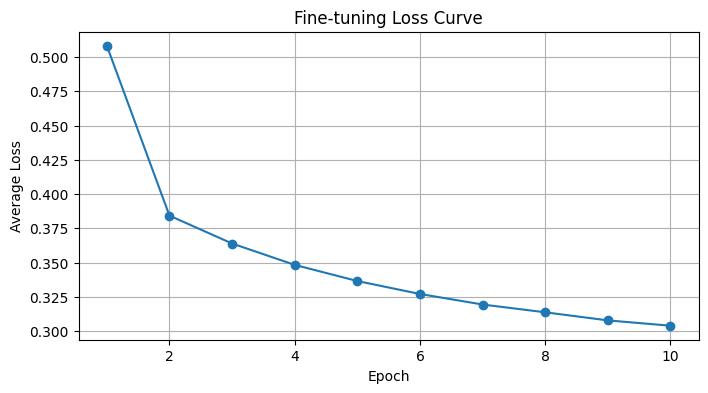

In [ ]:
from tqdm import tqdm
import torch.nn.functional as F
import matplotlib.pyplot as plt

fine_tune_head = False 

if fine_tune_head:
    # Freeze everything
    for param in classification_model.parameters():
        param.requires_grad = False

    # Unfreeze only the classification head
    for param in classification_model.head.parameters():
        param.requires_grad = True


else: 
    # Unfreeze whole model for fine-tuning 
    for param in classification_model.parameters():
        param.requires_grad = True

classification_model.train()
optimizer = torch.optim.Adam(classification_model.parameters(), lr=1e-5)
loss_fn = torch.nn.CrossEntropyLoss()

num_epochs = 10
epoch_losses = []  # 📉 Track average loss per epoch

for epoch in range(num_epochs):
    total_loss = 0
    loop = tqdm(finetune_loader, desc=f"🔧 Fine-tuning Epoch {epoch+1}/{num_epochs}")

    for batch in loop:
        x, mask, label, times, static, *_ = batch
        x = x.to(device).float()
        mask = mask.to(device).float()
        times = times.to(device).float()
        static = static.to(device).float()
        label = label.to(device).long()

        optimizer.zero_grad()
        logits = classification_model(x, static=static, time=times, sensor_mask=mask)
        loss = loss_fn(logits, label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(finetune_loader)
    epoch_losses.append(avg_loss)  # 🔍 Track loss
    print(f"✅ Epoch {epoch+1} finished. Avg Loss: {avg_loss:.4f}")

# 📊 Plot after training
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o')
plt.title("Fine-tuning Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.grid(True)
plt.show()


In [172]:
from torchmetrics.classification import BinaryAUROC, BinaryAveragePrecision

classification_model.eval()
auroc_metric = BinaryAUROC().to(device)
prroc_metric = BinaryAveragePrecision().to(device)

all_probs = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(eval_loader, desc="🔍 Evaluating Fine-Tuned Model"):
        x, mask, label, times, static, *_ = batch
        x = x.to(device).float()
        mask = mask.to(device).float()
        times = times.to(device).float()
        static = static.to(device).float()
        label = label.to(device).long()

        logits = classification_model(x, static=static, time=times, sensor_mask=mask)
        probs = torch.softmax(logits, dim=1)[:, 1]

        auroc_metric.update(probs, label)
        prroc_metric.update(probs, label)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(label.cpu().numpy())

# Final scores
final_auroc = auroc_metric.compute().item()
final_prroc = prroc_metric.compute().item()

print(f"\n🎯 Fine-Tuned Model AUROC: {final_auroc:.4f}")
print(f"🎯 Fine-Tuned Model PRROC: {final_prroc:.4f}")


🔍 Evaluating Fine-Tuned Model: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:07<00:00,  6.57it/s]


🎯 Fine-Tuned Model AUROC: 0.7809
🎯 Fine-Tuned Model PRROC: 0.3869
